# Do open concepts spread across more fields? (RQ2-D1 screen test)

This notebook is a runnable demo of the **RQ2-D1 screen test** from the study *"Occupancy is not integration"*, which looks at how emerging scientific concepts spread across disciplines in an evolving OpenAlex co-word network.

**Question.** A concept's ego network at year *t* can be more or less *open*. An open network has neighbours that are not linked to each other. A closed one has neighbours that form a dense clique. Does openness at *t* predict how far the concept spreads across disciplines in the next five years, **W2 = [t+1, t+5]**, once growth and level baselines are controlled for?

**Openness measures (at t):**
- `closure_res` (primary): top-20 Chung-Lu closure of the ego network, residualised on new-relation rate, novelty, beta_sim, log volume, age and W1 entropy. A higher value means a *more closed* network.
- `closure_res_imp`: the same measure with imputation. It was made co-primary by the pre-declared F3 row-count rule.
- Burt constraint, effective size / degree, and excess cross-community pairs.

**Outcomes (W2):**
- `Y1r`: change in rarefied Shannon entropy across subfields.
- `Y2`: change in Rao-Stirling diversity.
- `log1p_Y3`: number of new subfields reached by author-disjoint newcomers.

**BASE controls:** W1 entropy, active subfields, log volume, momentum, growing-edge breadth, Kleinberg burst state, Rafols coherence and P_rar, plus origin / F-band / route / year dummies.

**Pre-declared rule.** `D1_SUPPORTED_SCREEN` holds if, for some outcome, the closure coefficient is negative, its bootstrap CI excludes 0, the Holm-adjusted p is below 0.05 **and** the grouped-CV ΔR² CI lower bound is above 0. On the full screen, the result was **D1_NOT_SUPPORTED_SCREEN**.

### What this notebook runs
The original `method.py` is an orchestrator over 12 stages: vendor, population, prep, attach, indicators, openness, features, outcomes, models, power, freeze and outputs. The early stages need the hydrated 462,812-work corpus and 25 prebuilt co-word snapshots, which are far too large for a demo. This notebook starts from the **analysis panel** those stages produce (`results/d1/panel_ct.parquet`: features at *t* × W2 outcomes × E_up labels). It then runs the **`models` stage** (`src/models.py` with `src/stats_core.py`) essentially unchanged:
OLS + concept-cluster bootstrap + CR1, Holm/BH, grouped-by-concept CV ΔR², the rule/verdict, the within-E_up subset, the robustness grid, mediation, partial dependence, the VIF / volume check and the sanity checks.

`mini_demo_data.json` holds the 100 MAIN screen concepts that have complete-case `closure_res` (405 concept-year rows). The full panel has 659 rows and 168 concepts. The primary `closure_res` model therefore runs on (almost) exactly the same rows as the paper. The other measures run on a subset of their full-run rows.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, statsmodels, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'statsmodels==0.14.6', 'matplotlib==3.10.0')

## Imports
These are the import blocks of `method.py`, `src/models.py` and `src/stats_core.py`. The BLAS thread pinning from `method.py` is kept, because the original comment notes it makes these small dense solves about 1000x faster. The repository modules `common`, `lib_metrics`, `stats_core` and `openness` are inlined in the cells below. `matplotlib` is added for the final plots.

In [2]:
from __future__ import annotations

import os
import sys

for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(_v, "1")  # small dense solves: BLAS threading is ~1000x slower here
import time
import json
import math

import numpy as np
import pandas as pd
import statsmodels.api as sm
from loguru import logger
from scipy import stats

import matplotlib.pyplot as plt

# K.setup_logging("method") equivalent: stdout only (no log files in the notebook)
logger.remove()
_ = logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

## Data loading
The data is fetched from the GitHub repository, with a fallback to a local `mini_demo_data.json` next to the notebook.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/main/round-3/experiment-6/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(len(data["examples"]), "concepts,", sum(e["n_rows"] for e in data["examples"]), "concept-year rows")
print("full-run verdict:", data["metadata"]["full_run_verdict"])

100 concepts, 405 concept-year rows
full-run verdict: D1_NOT_SUPPORTED_SCREEN


## Configuration
These are all the tunable parameters, with the original values from the full run in the comments. `method.py --boot` defaulted to 2000, `--mini` used 200, and the robustness grid used 1000 (200 under `--mini`).

In [5]:
BOOT = 2000            # original: 2000 (method.py --boot); cluster-bootstrap reps for the primary models, E_up, mediation, PDP
BOOT_GRID = 1000       # original: 1000; bootstrap reps per robustness-grid specification (132 specs)
CV_REPS = 20           # original: 20 repeats of grouped 5-fold CV
CV_K = 5               # original: 5 folds
PDP_B_CAP = 1000       # original: min(B, 1000) bootstrap reps in the partial-dependence deciles
SANITY_PERM = 200      # original: 200 within-year placebo permutations
SANITY_SHUF = 10       # original: 10 label shuffles
SANITY_CV_REPS = 5     # original: 5 CV repeats inside the sanity checks
SANITY_BOOT_A, SANITY_BOOT_B = 1000, 2000   # original: bootstrap-stability comparison 1000 vs 2000
RUN_SANITY = True      # the sanity block is the slowest part; set False to skip
SEED = 20260929        # original seed

## Stage map of `method.py`
The orchestrator runs the stages below in order. Only `models` runs in this notebook. The `features` and `outcomes` stages produced the panel stored in `mini_demo_data.json`. `power`, `freeze` and `outputs` only post-process the model results.

In [6]:
STAGES = ["vendor", "population", "prep", "attach", "indicators", "openness", "features", "outcomes", "models",
          "power", "freeze", "outputs"]
STAGE_NOTES = {
    "vendor": "run vendored iteration-2 unit tests (not needed here)",
    "population": "frozen MAIN/STRICT/SENSITIVITY population; sealed held-out ids -> flags in_MAIN / in_STRICT / in_SENSITIVITY",
    "prep": "c-papers of 426 concepts from the 462,812-work corpus (too large for the demo)",
    "attach": "attach concepts to 25 co-word snapshots + ego-network openness (too large for the demo)",
    "indicators": "vendored per-(concept, year) indicators, E_up labels -> E_up_onset / E_up_group columns",
    "openness": "closure_res (R1a residualisation), constraint, effective size, xcomm -> *_z columns",
    "features": "W1 baselines at t -> BASE columns",
    "outcomes": "W2 outcomes Y1r, Y2, Y3 and mediator M_W2",
    "models": "RUN IN THIS NOTEBOOK",
    "power": "MDE simulation at held-out size (not run)",
    "freeze": "held-out spec + sha256 (not run)",
    "outputs": "method_out.json, figures (replaced by the final cell)",
}
for st in STAGES:
    print(f"{st:>11}: {STAGE_NOTES[st]}")

     vendor: run vendored iteration-2 unit tests (not needed here)
 population: frozen MAIN/STRICT/SENSITIVITY population; sealed held-out ids -> flags in_MAIN / in_STRICT / in_SENSITIVITY
       prep: c-papers of 426 concepts from the 462,812-work corpus (too large for the demo)
     attach: attach concepts to 25 co-word snapshots + ego-network openness (too large for the demo)
 indicators: vendored per-(concept, year) indicators, E_up labels -> E_up_onset / E_up_group columns
   openness: closure_res (R1a residualisation), constraint, effective size, xcomm -> *_z columns
   features: W1 baselines at t -> BASE columns
   outcomes: W2 outcomes Y1r, Y2, Y3 and mediator M_W2
     models: RUN IN THIS NOTEBOOK
      power: MDE simulation at held-out size (not run)
     freeze: held-out spec + sha256 (not run)
    outputs: method_out.json, figures (replaced by the final cell)


## Model helpers (`src/stats_core.py`, verbatim)
- `design` builds `[const, lead..., BASE numerics..., drop-first dummies]`. The openness variable always sits in column 1.
- `cr1` gives Stata-style cluster-robust SEs, clustered by concept.
- `cluster_boot` resamples whole concepts, so the repeated years of one concept stay together.
- `grouped_cv` gives out-of-fold predictions from grouped-by-concept K-fold CV repeated `reps` times. No concept is ever in both train and test.
- `delta_r2_boot` computes the out-of-fold R² gain of FULL (BASE + openness) over BASE, with a concept-bootstrap CI.

In [7]:
NUM_BASE = ["H_W1", "n_active_W1", "log_vol_W1", "momentum", "GEB", "burst_state", "rafols_coh_f", "coh_missing",
            "P_rar_f", "P_rar_missing"]
CATS = ["origin_group", "F_band", "route", "t"]
TURNOVER = ["new_relation_rate", "novelty", "beta_sim_rar_f", "beta_sim_missing"]


def design(d: pd.DataFrame, lead: list[str], num: list[str] = NUM_BASE, cats: list[str] = CATS,
           levels: dict | None = None) -> tuple[np.ndarray, list[str], dict]:
    """[const, lead..., num..., drop-first dummies]; lead columns sit at positions 1..len(lead).

    `levels` (from a previous call) freezes dummy coding, e.g. for held-out rows.
    """
    cols = [np.ones(len(d))]
    names = ["const"]
    for c in lead + num:
        cols.append(d[c].astype(float).values)
        names.append(c)
    lv_out = {}
    for c in cats:
        vals = d[c].astype(str).values
        lv = levels[c] if levels is not None else sorted(set(vals))
        lv_out[c] = lv
        for v in lv[1:]:
            cols.append((vals == v).astype(float))
            names.append(f"{c}={v}")
    X = np.column_stack(cols)
    if levels is None:  # drop constant dummy / numeric columns (never const or lead)
        keep = [i for i in range(X.shape[1]) if i <= len(lead) or np.ptp(X[:, i]) > 0]
        X = X[:, keep]
        names = [names[i] for i in keep]
    return X, names, lv_out


def ols(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    return np.linalg.lstsq(X, y, rcond=None)[0]


def cr1(X: np.ndarray, y: np.ndarray, g: np.ndarray, beta: np.ndarray | None = None) -> tuple[np.ndarray, np.ndarray]:
    """Coefficients and CR1 cluster-robust SEs (Stata small-sample factor)."""
    beta = ols(X, y) if beta is None else beta
    u = y - X @ beta
    n, k = X.shape
    XtXi = np.linalg.pinv(X.T @ X)
    uniq, inv = np.unique(g, return_inverse=True)
    G = len(uniq)
    S = np.zeros((G, k))
    np.add.at(S, inv, X * u[:, None])
    meat = S.T @ S
    V = XtXi @ meat @ XtXi * (G / (G - 1)) * ((n - 1) / max(n - k, 1))
    return beta, np.sqrt(np.clip(np.diag(V), 0, None))


def blocks_of(g: np.ndarray) -> list[np.ndarray]:
    uniq, inv = np.unique(g, return_inverse=True)
    order = np.argsort(inv, kind="stable")
    cuts = np.cumsum(np.bincount(inv))[:-1]
    return np.split(order, cuts)


def cluster_boot(X: np.ndarray, y: np.ndarray, g: np.ndarray, B: int, seed: int, j: int | list = 1) -> np.ndarray:
    blocks = blocks_of(g)
    G = len(blocks)
    rng = np.random.default_rng(seed)
    jj = np.atleast_1d(j)
    out = np.empty((B, len(jj)))
    for b in range(B):
        idx = np.concatenate([blocks[k] for k in rng.integers(0, G, G)])
        out[b] = ols(X[idx], y[idx])[jj]
    return out[:, 0] if np.ndim(j) == 0 else out


def boot_summary(est: float, draws: np.ndarray) -> dict:
    B = len(draws)
    lo, hi = np.percentile(draws, [2.5, 97.5])
    n_le, n_ge = int(np.sum(draws <= 0)), int(np.sum(draws >= 0))
    p = min(1.0, 2 * min((n_le + 1) / (B + 1), (n_ge + 1) / (B + 1)))
    return dict(coef=float(est), ci_lo=float(lo), ci_hi=float(hi), p_boot=float(p), boot_sd=float(np.std(draws, ddof=1)))


def r2(y: np.ndarray, p: np.ndarray) -> float:
    sst = float(np.sum((y - y.mean()) ** 2))
    return float(1 - np.sum((y - p) ** 2) / sst) if sst > 0 else math.nan


def fold_assign(g: np.ndarray, k: int, seed: int) -> np.ndarray:
    """Concepts shuffled (seeded) then dealt round-robin into k folds (grouped K-fold with shuffled group order)."""
    uniq = np.unique(g)
    perm = np.random.default_rng(seed).permutation(uniq)
    f_of = {c: i % k for i, c in enumerate(perm)}
    return np.array([f_of[c] for c in g])


def grouped_cv(Xb: np.ndarray, Xf: np.ndarray | None, y: np.ndarray, g: np.ndarray, reps: int = 20, k: int = 5,
               xf_fn=None) -> tuple[np.ndarray, np.ndarray]:
    """OOF predictions (averaged over repeats) for BASE and FULL; xf_fn(train_mask) -> FULL design (fold-internal)."""
    n = len(y)
    pb, pf = np.zeros((reps, n)), np.zeros((reps, n))
    for r in range(reps):
        f = fold_assign(g, k, r)
        for i in range(k):
            tr, te = f != i, f == i
            pb[r, te] = Xb[te] @ ols(Xb[tr], y[tr])
            XF = xf_fn(tr) if xf_fn is not None else Xf
            pf[r, te] = XF[te] @ ols(XF[tr], y[tr])
    return pb.mean(0), pf.mean(0)


def delta_r2_boot(y: np.ndarray, pb: np.ndarray, pf: np.ndarray, g: np.ndarray, B: int, seed: int) -> dict:
    blocks = blocks_of(g)
    G = len(blocks)
    rng = np.random.default_rng(seed)
    d = np.empty(B)
    for b in range(B):
        idx = np.concatenate([blocks[k] for k in rng.integers(0, G, G)])
        d[b] = r2(y[idx], pf[idx]) - r2(y[idx], pb[idx])
    lo, hi = np.percentile(d, [2.5, 97.5])
    return dict(r2_base=r2(y, pb), r2_full=r2(y, pf), delta_r2=r2(y, pf) - r2(y, pb), ci_lo=float(lo), ci_hi=float(hi))


def t_p_two_sided(coef: float, se: float, df: int) -> float:
    if not (np.isfinite(se) and se > 0):
        return math.nan
    return float(2 * stats.t.sf(abs(coef / se), df))

## Multiplicity helpers (vendored `lib_metrics.holm` / `lib_metrics.bh`, verbatim) and the R1a regressor list
In `models.py` these come in through `import lib_metrics as lm`, `import stats_core as S` and `from openness import R1A`. Two small namespaces, `S` and `lm`, keep the original call sites (`S.design`, `lm.holm`, ...) unchanged.

In [8]:
from types import SimpleNamespace
from typing import Sequence


def holm(pvals: Sequence[float]) -> list[float]:
    """Holm step-down adjusted p-values (NaN entries passed through)."""
    p = np.asarray(pvals, dtype=float)
    out = np.full_like(p, np.nan)
    ok = np.where(np.isfinite(p))[0]
    order = ok[np.argsort(p[ok])]
    m = len(order)
    running = 0.0
    for rank, idx in enumerate(order):
        adj = min(1.0, (m - rank) * p[idx])
        running = max(running, adj)
        out[idx] = running
    return out.tolist()


def bh(pvals: Sequence[float]) -> list[float]:
    """Benjamini-Hochberg q-values (NaN entries passed through)."""
    p = np.asarray(pvals, dtype=float)
    out = np.full_like(p, np.nan)
    ok = np.where(np.isfinite(p))[0]
    if ok.size == 0:
        return out.tolist()
    order = ok[np.argsort(p[ok])]
    m = len(order)
    q = p[order] * m / np.arange(1, m + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    out[order] = np.minimum(q, 1.0)
    return out.tolist()


R1A = ["new_relation_rate", "novelty", "beta_sim_rar", "log_vol3", "age"]   # from src/openness.py

S = SimpleNamespace(NUM_BASE=NUM_BASE, CATS=CATS, TURNOVER=TURNOVER, design=design, ols=ols, cr1=cr1, blocks_of=blocks_of,
                    cluster_boot=cluster_boot, boot_summary=boot_summary, r2=r2, fold_assign=fold_assign,
                    grouped_cv=grouped_cv, delta_r2_boot=delta_r2_boot, t_p_two_sided=t_p_two_sided)
lm = SimpleNamespace(holm=holm, bh=bh)

## Loading the analysis panel (`models.load_panel`)
In the original, `load_panel()` merges `features_ct.parquet` with `outcomes_ct.parquet`, median-fills `beta_sim_rar`, attaches the E_up labels and adds `routeA`. It then writes the result to `results/d1/panel_ct.parquet`. `mini_demo_data.json` contains exactly those panel rows, so the version below rebuilds the DataFrame from the loaded `data` instead of the parquet files. The original merge code is kept in comments.

Each row is one **(concept, t)** pair, with *t* between 2008 and 2015 and concept age between 3 and 8. The flags `in_MAIN`, `in_STRICT` and `in_SENSITIVITY` mark the three population definitions.

In [9]:
OUTCOMES = ["Y1r", "Y2", "log1p_Y3"]
RULE_TEXT = ("D1_SUPPORTED_SCREEN = exists Y in {Y1r, Y2, Y3}: coef(closure_res) < 0 AND bootstrap CI excludes 0 AND "
             "Holm-adjusted p < 0.05 AND grouped-CV delta-R2 CI lower bound > 0 for that same Y. Else "
             "D1_NOT_SUPPORTED_SCREEN. If the sibling RQ1 holds and D1 fails -> 'take-off correlate only'. Sign > 0 with CI "
             "excluding 0 -> 'closure predicts breadth in the OPPOSITE direction' (reported, rule not met).")


def load_panel() -> pd.DataFrame:
    # original:
    # F = pd.read_parquet(FDIR / "features_ct.parquet")
    # O = pd.read_parquet(FDIR / "outcomes_ct.parquet")
    # d = F.merge(O, on=["concept_id", "t"], how="inner")
    # med = float(d.beta_sim_rar.median()); d["beta_sim_missing"] = ...; d["beta_sim_rar_f"] = d.beta_sim_rar.fillna(med)
    # lab = pd.read_parquet(OUT / "indicators" / "labels_screen.parquet") ... -> E_up_onset, E_up_group
    # d["E_up"] = d.E_up_onset.notna(); d["routeA"] = (d.route == "A_openalex_native").astype(float)
    # -> the resulting panel (results/d1/panel_ct.parquet) is what mini_demo_data.json stores, one example per concept
    rows = [r for ex in data["examples"] for r in ex["rows"]]
    d = pd.DataFrame(rows, columns=data["metadata"]["columns"])
    for c in ["in_MAIN", "in_STRICT", "in_SENSITIVITY", "sense_check_fail", "E_up"]:
        d[c] = d[c].astype(bool)
    return d


def pop_mask(d: pd.DataFrame, pop: str) -> np.ndarray:
    return {"MAIN": d.in_MAIN, "STRICT": d.in_STRICT, "SENSITIVITY": d.in_SENSITIVITY}[pop].values.astype(bool)


def model_rows(d: pd.DataFrame, y: str, lead: list[str], num: list[str]) -> pd.DataFrame:
    cols = [y] + lead + num
    ok = np.isfinite(d[cols].astype(float).values).all(1)
    return d[ok].reset_index(drop=True)


d = load_panel()
dec = data["metadata"]["row_count_decision"]   # original: json.loads((FDIR / "rowcount_decision.json").read_text())
print(d.shape, "| concepts:", d.concept_id.nunique(), "| MAIN rows:", int(d.in_MAIN.sum()),
      "| STRICT rows:", int(d.in_STRICT.sum()), "| E_up concepts:", d[d.E_up].concept_id.nunique())
print("F3 co-primary rule triggered (full screen):", dec["F3_triggered"])
d[["concept_id", "phrase", "t", "closure_res_z", "closure_res_imp_z", "H_W1", "log_vol_W1", "Y1r", "Y2", "log1p_Y3"]].head()

(405, 84) | concepts: 100 | MAIN rows: 405 | STRICT rows: 395 | E_up concepts: 67
F3 co-primary rule triggered (full screen): True


,concept_id,phrase,t,closure_res_z,closure_res_imp_z,H_W1,log_vol_W1,Y1r,Y2,log1p_Y3
0,c_007a7950eb4d,dantzig selector,2010,-0.848240,-0.511455,1.669867,3.970292,0.059947,0.004366,2.564949
1,c_007a7950eb4d,dantzig selector,2011,1.410150,1.773755,1.805378,4.317488,0.026722,-0.008103,2.484907
2,c_007a7950eb4d,dantzig selector,2012,0.682154,0.857072,1.922647,4.634729,-0.057937,-0.016203,2.397895
3,c_007a7950eb4d,dantzig selector,2013,0.661124,0.728385,1.815934,4.744932,0.139056,0.014230,2.302585
4,c_007a7950eb4d,dantzig selector,2014,0.508106,0.531624,1.771636,4.812184,0.280588,0.041997,2.197225


## Fitting one model: OLS + cluster bootstrap (`fit_one`) and grouped CV ΔR² (`cv_one`)
`fit_one` estimates **Y ~ openness_z + BASE + dummies** on the complete-case rows. It reports the openness coefficient with a concept-cluster bootstrap CI and p-value, the CR1 SE and p-value, and the coefficient in SD(Y) units.

`cv_one` compares out-of-fold R² for FULL versus BASE (BASE is the same design with the openness column removed).

Two changes are needed in the notebook: `reps` now defaults to the `CV_REPS` config value, and the `foldwise=True` branch is disabled. That branch refits the R1a residualisation inside each training fold, which needs the 2.4 MB per-year indicator table `work/indicators_open.parquet`. That table is not part of the demo data. Its full-run result is quoted in the final cell.

In [10]:
def fit_one(d: pd.DataFrame, y: str, open_var: str, num: list[str] = S.NUM_BASE, B: int = 2000, seed: int = SEED,
            extra_lead: list[str] | None = None, cats: list[str] = S.CATS) -> dict:
    lead = [open_var] + (extra_lead or [])
    m = model_rows(d, y, lead, num)
    if m.concept_id.nunique() < 10:
        return dict(n_rows=len(m), n_concepts=int(m.concept_id.nunique()), coef=math.nan, note="too few concepts")
    X, names, _ = S.design(m, lead, num, cats)
    yy = m[y].astype(float).values
    g = m.concept_id.values
    beta, se = S.cr1(X, yy, g)
    draws = S.cluster_boot(X, yy, g, B, seed, 1)
    out = S.boot_summary(beta[1], draws)
    G = m.concept_id.nunique()
    out.update(se_cr1=float(se[1]), p_cr1=S.t_p_two_sided(beta[1], se[1], G - 1), n_rows=len(m), n_concepts=int(G),
               n_params=X.shape[1], sd_y=float(yy.std(ddof=1)), coef_in_sd_y=float(beta[1] / yy.std(ddof=1)))
    if extra_lead:
        for k, nm in enumerate(extra_lead, start=2):
            out[f"coef_{nm}"] = float(beta[k])
            out[f"se_cr1_{nm}"] = float(se[k])
    return out


def cv_one(d: pd.DataFrame, y: str, open_var: str, num: list[str] = S.NUM_BASE, B: int = 2000, reps: int = CV_REPS,
           foldwise: bool = False, seed: int = SEED + 7, extra_full: list[str] | None = None) -> dict:
    lead = [open_var] + (extra_full or [])
    m = model_rows(d, y, lead, num)
    Xf, names, _ = S.design(m, lead, num)
    Xb = np.delete(Xf, list(range(1, 1 + len(lead))), axis=1)
    yy = m[y].astype(float).values
    g = m.concept_id.values
    xf_fn = None
    if foldwise:
        # needs work/indicators_open.parquet (per concept-year R1a fit rows), not shipped with the demo data
        raise NotImplementedError("fold-internal R1a residualisation needs work/indicators_open.parquet")
    pb, pf = S.grouped_cv(Xb, Xf, yy, g, reps=reps, k=CV_K, xf_fn=xf_fn)
    out = S.delta_r2_boot(yy, pb, pf, g, B, seed)
    out.update(n_rows=len(m), n_concepts=int(m.concept_id.nunique()), foldwise=foldwise)
    return out, m.assign(oof_base=pb, oof_full=pf)

## (a) + (b) Primary models and the pre-declared rule (`primary`, `evaluate_rule`)
This fits all five openness measures × three outcomes on the MAIN population. Multiplicity is handled with Holm over the three outcomes for each co-primary measure (`closure_res_z`, `closure_res_imp_z`) and with BH over the secondary measures (constraint and effective size).

`evaluate_rule` checks the four pre-declared conditions for each outcome. The F3 rule was triggered on the full screen, because complete-case `closure_res` left only 100 concepts / 351 rows. The verdict therefore requires the rule to hold for **both** co-primary measures on the same outcome.

In [11]:
def primary(d: pd.DataFrame, B: int) -> tuple[pd.DataFrame, pd.DataFrame, dict, dict]:
    dm = d[pop_mask(d, "MAIN")]
    coef_rows, cv_rows, oof = [], [], {}
    for ov in ["closure_res_z", "closure_res_imp_z", "constraint_z", "esize_norm_z", "xcomm_exc_z"]:
        for y in OUTCOMES:
            r = fit_one(dm, y, ov, B=B)
            coef_rows.append(dict(model="a_primary_OLS", population="MAIN", openness=ov, outcome=y, **r))
            c, m = cv_one(dm, y, ov, B=B)
            cv_rows.append(dict(model="b_grouped_cv", population="MAIN", openness=ov, outcome=y, **c))
            if ov in ("closure_res_z", "closure_res_imp_z"):
                oof[(ov, y)] = m
                # original: foldwise=True variant for closure_res_z (needs work/indicators_open.parquet; skipped)
            logger.info(f"{ov:>18} {y:>9}: coef {r['coef']:+.4f} [{r['ci_lo']:+.4f}, {r['ci_hi']:+.4f}] p_boot {r['p_boot']:.4f} "
                        f"n={r['n_rows']}/{r['n_concepts']} | dR2 {c['delta_r2']:+.4f} [{c['ci_lo']:+.4f}, {c['ci_hi']:+.4f}]")
    coef = pd.DataFrame(coef_rows)
    cv = pd.DataFrame(cv_rows)
    # multiplicity: Holm over the 3 outcomes within each co-primary measure; BH over the secondary measures
    coef["p_holm"] = np.nan
    coef["q_bh_secondary"] = np.nan
    for ov in ["closure_res_z", "closure_res_imp_z"]:
        mk = coef.openness == ov
        coef.loc[mk, "p_holm"] = lm.holm(coef.loc[mk, "p_boot"].tolist())
    mk = coef.openness.isin(["constraint_z", "esize_norm_z"])
    coef.loc[mk, "q_bh_secondary"] = lm.bh(coef.loc[mk, "p_boot"].tolist())
    return coef, cv, oof, {}


def evaluate_rule(coef: pd.DataFrame, cv: pd.DataFrame, ov: str) -> dict:
    per = {}
    for y in OUTCOMES:
        a = coef[(coef.openness == ov) & (coef.outcome == y) & (coef.model == "a_primary_OLS")].iloc[0]
        b = cv[(cv.openness == ov) & (cv.outcome == y) & (cv.model == "b_grouped_cv")].iloc[0]
        cond = dict(coef_negative=bool(a.coef < 0), ci_excludes_0=bool(a.ci_hi < 0 or a.ci_lo > 0),
                    holm_p_lt_005=bool(a.p_holm < 0.05), cv_delta_r2_ci_lo_gt_0=bool(b.ci_lo > 0))
        per[y] = dict(conditions=cond, met=all(cond.values()),
                      opposite_direction=bool(a.coef > 0 and a.ci_lo > 0),
                      coef=float(a.coef), ci=[float(a.ci_lo), float(a.ci_hi)], p_boot=float(a.p_boot),
                      p_holm=float(a.p_holm), delta_r2=float(b.delta_r2), delta_r2_ci=[float(b.ci_lo), float(b.ci_hi)])
    return per

Run the primary models and derive the verdict. This is the body of `models.run()`. The file writes are replaced by in-memory variables.

In [12]:
t0 = time.time()
B = BOOT
Bg = BOOT_GRID
coef, cv, oof, _ = primary(d, B)
verdict = dict(rule_text_verbatim=RULE_TEXT, row_count_decision=dec)
per = {ov: evaluate_rule(coef, cv, ov) for ov in ["closure_res_z", "closure_res_imp_z"]}
verdict["per_measure"] = per
met_primary = [y for y, v in per["closure_res_z"].items() if v["met"]]
met_imp = [y for y, v in per["closure_res_imp_z"].items() if v["met"]]
if dec.get("F3_triggered"):
    met = [y for y in met_primary if y in met_imp]
    verdict["co_primary_note"] = dec.get("coprimary_rule")
else:
    met = met_primary
verdict["outcomes_meeting_rule"] = met
verdict["verdict"] = "D1_SUPPORTED_SCREEN" if met else "D1_NOT_SUPPORTED_SCREEN"
opp = [y for y, v in per["closure_res_z"].items() if v["opposite_direction"]]
verdict["opposite_direction_outcomes"] = opp
verdict["interpretation"] = ("closure (low openness) predicts breadth gain in the pre-declared direction on the screen"
                             if met else ("closure predicts breadth in the OPPOSITE direction (rule not met)" if opp else
                                          "no screen support: openness is a take-off correlate only (if RQ1 holds)"))
logger.info(f"VERDICT: {verdict['verdict']} (met: {met}; opposite: {opp})")
print(f"primary block: {time.time() - t0:.1f}s")
for ov, pm in per.items():
    for y, v in pm.items():
        print(f"{ov:>18} {y:>9}: met={v['met']!s:5} conditions={v['conditions']}")

12:24:59|INFO   |     closure_res_z       Y1r: coef +0.0194 [-0.0098, +0.0408] p_boot 0.1989 n=347/98 | dR2 +0.0067 [-0.0151, +0.0305]


12:25:00|INFO   |     closure_res_z        Y2: coef +0.0070 [-0.0024, +0.0133] p_boot 0.1349 n=351/100 | dR2 +0.0123 [-0.0129, +0.0426]


12:25:00|INFO   |     closure_res_z  log1p_Y3: coef -0.0650 [-0.1556, +0.0299] p_boot 0.1759 n=351/100 | dR2 +0.0011 [-0.0123, +0.0146]


12:25:01|INFO   | closure_res_imp_z       Y1r: coef +0.0237 [-0.0045, +0.0463] p_boot 0.1049 n=394/99 | dR2 +0.0117 [-0.0159, +0.0426]


12:25:02|INFO   | closure_res_imp_z        Y2: coef +0.0089 [+0.0002, +0.0155] p_boot 0.0460 n=405/100 | dR2 +0.0235 [-0.0090, +0.0628]


...

12:25:06|INFO   |       xcomm_exc_z       Y1r: coef +0.0109 [-0.0177, +0.0385] p_boot 0.4628 n=371/98 | dR2 -0.0079 [-0.0187, +0.0024]


12:25:06|INFO   |       xcomm_exc_z        Y2: coef +0.0042 [-0.0039, +0.0132] p_boot 0.3438 n=382/99 | dR2 -0.0048 [-0.0203, +0.0072]


12:25:07|INFO   |       xcomm_exc_z  log1p_Y3: coef +0.0613 [-0.0446, +0.1682] p_boot 0.2799 n=382/99 | dR2 -0.0017 [-0.0110, +0.0074]


12:25:07|INFO   |VERDICT: D1_NOT_SUPPORTED_SCREEN (met: []; opposite: [])


primary block: 7.8s
     closure_res_z       Y1r: met=False conditions={'coef_negative': False, 'ci_excludes_0': False, 'holm_p_lt_005': False, 'cv_delta_r2_ci_lo_gt_0': False}
     closure_res_z        Y2: met=False conditions={'coef_negative': False, 'ci_excludes_0': False, 'holm_p_lt_005': False, 'cv_delta_r2_ci_lo_gt_0': False}
     closure_res_z  log1p_Y3: met=False conditions={'coef_negative': True, 'ci_excludes_0': False, 'holm_p_lt_005': False, 'cv_delta_r2_ci_lo_gt_0': False}
 closure_res_imp_z       Y1r: met=False conditions={'coef_negative': False, 'ci_excludes_0': False, 'holm_p_lt_005': False, 'cv_delta_r2_ci_lo_gt_0': False}
 closure_res_imp_z        Y2: met=False conditions={'coef_negative': False, 'ci_excludes_0': True, 'holm_p_lt_005': False, 'cv_delta_r2_ci_lo_gt_0': False}
 closure_res_imp_z  log1p_Y3: met=False conditions={'coef_negative': True, 'ci_excludes_0': False, 'holm_p_lt_005': False, 'cv_delta_r2_ci_lo_gt_0': False}


## (c) Within E_up concepts (`within_eup`)
This restricts the data to concepts that the RQ1 labeller flagged as emerging (E_up onset ≤ 2015), keeping the rows from 3 years before onset up to onset. It asks whether openness is informative right around take-off. The subset is small, so it is descriptive only; in the full run the MDE was above 0.5 SD.

In [13]:
def within_eup(d: pd.DataFrame, B: int) -> dict:
    dm = d[pop_mask(d, "MAIN") & d.E_up.values]
    dm = dm[(dm.t >= dm.E_up_onset - 3) & (dm.t <= dm.E_up_onset) & (dm.E_up_onset <= 2015)]
    res = dict(n_concepts=int(dm.concept_id.nunique()), n_rows=len(dm),
               rule="concepts with E_up onset <= 2015; rows t in [onset-3, onset], age 3..8, MAIN")
    res["underpowered"] = bool(res["n_concepts"] < 30)
    rows = []
    for ov in ["closure_res_z", "closure_res_imp_z", "constraint_z"]:
        for y in OUTCOMES:
            r = fit_one(dm, y, ov, B=B)
            try:
                c, _ = cv_one(dm, y, ov, B=B)
            except (np.linalg.LinAlgError, ValueError) as e:
                logger.warning(f"E_up CV failed {ov} {y}: {e}")
                c = {}
            rows.append(dict(openness=ov, outcome=y, **r, **{f"cv_{k}": v for k, v in c.items()}))
    res["estimates"] = rows
    res["label"] = "UNDERPOWERED - descriptive only" if res["underpowered"] else "secondary analysis"
    return res


t0 = time.time()
eup = within_eup(d, B)
logger.info(f"E_up subset: {eup['n_concepts']} concepts / {eup['n_rows']} rows ({eup['label']})")
print(f"E_up block: {time.time() - t0:.1f}s")
pd.DataFrame(eup["estimates"])[["openness", "outcome", "coef", "ci_lo", "ci_hi", "p_boot", "n_rows", "n_concepts"]].round(4)

12:25:10|INFO   |E_up subset: 67 concepts / 77 rows (secondary analysis)


E_up block: 2.8s


,openness,outcome,coef,ci_lo,ci_hi,p_boot,n_rows,n_concepts
0,closure_res_z,Y1r,0.0137,-0.0821,0.0988,0.8406,67,62
1,closure_res_z,Y2,0.0055,-0.0240,0.0328,0.7886,67,62
2,closure_res_z,log1p_Y3,-0.0790,-0.4518,0.2408,0.5527,67,62
3,closure_res_imp_z,Y1r,0.0178,-0.0699,0.0958,0.6927,76,67
4,closure_res_imp_z,Y2,0.0063,-0.0205,0.0306,0.6947,77,67
5,closure_res_imp_z,log1p_Y3,-0.0466,-0.3565,0.2259,0.7136,77,67
6,constraint_z,Y1r,-0.0832,-0.1914,0.0147,0.0990,76,67
7,constraint_z,Y2,-0.0241,-0.0553,0.0056,0.1179,77,67
8,constraint_z,log1p_Y3,0.0863,-0.2285,0.3946,0.6257,77,67


## (d) Robustness grid (`robustness`)
This re-fits the model under alternative populations (STRICT, SENSITIVITY), route and hydration-batch subsets, a route interaction, one row per concept, a turnover-augmented baseline, an extra origin-proximity control, a drop of sense-check failures, alternative outcomes (Y1, Y1r20, log1p_Y3b) and alternative openness constructions. It adds a Poisson QMLE (PPML) fit for the count outcome Y3.

The demo data only contains MAIN concepts, so the SENSITIVITY rows here are just the MAIN concepts' rows.

In [14]:
def robustness(d: pd.DataFrame, B: int) -> pd.DataFrame:
    specs = []
    for ov in ["closure_res_z", "closure_res_imp_z", "constraint_z"]:
        for y in OUTCOMES:
            specs += [
                dict(spec="MAIN (primary)", pop="MAIN", ov=ov, y=y),
                dict(spec="STRICT", pop="STRICT", ov=ov, y=y),
                dict(spec="SENSITIVITY (all main arm)", pop="SENSITIVITY", ov=ov, y=y),
                dict(spec="route A only", pop="MAIN", ov=ov, y=y, filt=lambda x: x.route == "A_openalex_native"),
                dict(spec="route B only", pop="MAIN", ov=ov, y=y, filt=lambda x: x.route == "B_s2_index"),
                dict(spec="route interaction", pop="MAIN", ov=ov, y=y, inter="routeA"),
                dict(spec="iteration-1 concepts (hydration_batch iter1)", pop="MAIN", ov=ov, y=y, filt=lambda x: x.hydration_batch == "iter1"),
                dict(spec="newly hydrated concepts (iter2)", pop="MAIN", ov=ov, y=y, filt=lambda x: x.hydration_batch == "iter2"),
                dict(spec="one row per concept (first eligible t)", pop="MAIN", ov=ov, y=y, first=True),
                dict(spec="turnover-augmented baseline", pop="MAIN", ov=ov, y=y, num=S.NUM_BASE + S.TURNOVER),
                dict(spec="+ origin-subfield proximity", pop="MAIN", ov=ov, y=y, num=S.NUM_BASE + ["origin_prox_f", "prox_missing"]),
                dict(spec="drop sense_check_fail", pop="MAIN", ov=ov, y=y, filt=lambda x: ~x.sense_check_fail.astype(bool)),
            ]
        for y2 in ["Y1", "Y1r20", "log1p_Y3b"]:
            specs.append(dict(spec=f"alt outcome {y2}", pop="MAIN", ov=ov, y=y2))
    for y in OUTCOMES:
        specs += [dict(spec="closure_unres (no residualisation)", pop="MAIN", ov="closure_unres_z", y=y),
                  dict(spec="closure_res_H3 (3-yr H in R1a)", pop="MAIN", ov="closure_res_H3_z", y=y),
                  dict(spec="W1-mean closure_res over [t-2, t]", pop="MAIN", ov="closure_res_w1mean_z", y=y),
                  dict(spec="xcomm_exc (cross-community pairs)", pop="MAIN", ov="xcomm_exc_z", y=y)]
    d = d.copy()
    d["log1p_Y3b"] = np.log1p(d.Y3b)
    if "Y1r20" not in d.columns:
        d["Y1r20"] = d.filter(regex=r"^Y1r\d+$").iloc[:, 0]
    rows = []
    for k, s in enumerate(specs):
        x = d[pop_mask(d, s["pop"])]
        if "filt" in s:
            x = x[s["filt"](x).values]
        if s.get("first"):
            x = model_rows(x, s["y"], [s["ov"]], s.get("num", S.NUM_BASE)).sort_values("t").drop_duplicates("concept_id")
        extra = None
        if s.get("inter"):
            x = x.assign(open_x_routeA=x[s["ov"]] * x[s["inter"]])
            extra = ["open_x_routeA"]
        cats = [c for c in S.CATS if not (s.get("first") and c == "t")] if s.get("first") else S.CATS
        r = fit_one(x, s["y"], s["ov"], num=s.get("num", S.NUM_BASE), B=B, seed=SEED + k, extra_lead=extra, cats=cats)
        rows.append(dict(spec=s["spec"], population=s["pop"], openness=s["ov"], outcome=s["y"], estimator="OLS", **r))
    # PPML for Y3 (Poisson QMLE, cluster-robust)
    for ov in ["closure_res_z", "closure_res_imp_z", "constraint_z"]:
        x = model_rows(d[pop_mask(d, "MAIN")], "Y3", [ov], S.NUM_BASE)
        X, names, _ = S.design(x, [ov])
        try:
            res = sm.GLM(x.Y3.astype(float).values, X, family=sm.families.Poisson()).fit(
                cov_type="cluster", cov_kwds={"groups": pd.factorize(x.concept_id)[0]})
            b, se = float(res.params[1]), float(res.bse[1])
            rows.append(dict(spec="PPML Y3 (Poisson QMLE, CR)", population="MAIN", openness=ov, outcome="Y3", estimator="PPML",
                             coef=b, ci_lo=b - 1.96 * se, ci_hi=b + 1.96 * se, se_cr1=se, p_cr1=float(res.pvalues[1]),
                             n_rows=len(x), n_concepts=int(x.concept_id.nunique())))
        except (np.linalg.LinAlgError, ValueError) as e:
            logger.warning(f"PPML failed for {ov}: {e}")
    return pd.DataFrame(rows)


t0 = time.time()
rob = robustness(d, Bg)
logger.info(f"robustness grid: {len(rob)} rows")
print(f"robustness block: {time.time() - t0:.1f}s")

12:25:31|INFO   |robustness grid: 132 rows


robustness block: 21.8s


## (e) Descriptive mediation (`mediation`)
This decomposes the openness → Y effect through **M_W2**, the mean excess cross-community pair share over t+1..t+5:
- a = effect of openness on M
- b = effect of M on Y given openness
- indirect effect = a·b
- total effect c and direct effect c′

All CIs come from the concept bootstrap. M_W2 is measured after *t*, so this decomposition is descriptive, not causal.

In [15]:
def mediation(d: pd.DataFrame, B: int, ov: str = "closure_res_z") -> dict:
    dm = d[pop_mask(d, "MAIN")]
    out = dict(note="M_W2 (mean excess cross-community pair share over t+1..t+5) is post-t: the decomposition is "
                    "descriptive, not causal.", openness=ov, per_outcome={})
    for y in OUTCOMES:
        m = model_rows(dm, y, [ov, "M_W2"], S.NUM_BASE)
        Xc, _, _ = S.design(m, [ov])
        Xb, _, _ = S.design(m, [ov, "M_W2"])
        yy, mm, g = m[y].astype(float).values, m.M_W2.astype(float).values, m.concept_id.values

        def est(idx):
            a = S.ols(Xc[idx], mm[idx])[1]
            bb = S.ols(Xb[idx], yy[idx])
            c = S.ols(Xc[idx], yy[idx])[1]
            return np.array([a, bb[2], a * bb[2], c, bb[1], (a * bb[2] / c) if c != 0 else np.nan])
        full = est(np.arange(len(m)))
        blocks = S.blocks_of(g)
        rng = np.random.default_rng(SEED + 99)
        draws = np.array([est(np.concatenate([blocks[k] for k in rng.integers(0, len(blocks), len(blocks))])) for _ in range(B)])
        names = ["a_path", "b_path", "indirect_ab", "total_c", "direct_c_prime", "proportion_mediated"]
        out["per_outcome"][y] = dict(n_rows=len(m), n_concepts=int(m.concept_id.nunique()),
                                     **{n: dict(est=float(full[i]), ci=[float(np.nanpercentile(draws[:, i], 2.5)),
                                                                        float(np.nanpercentile(draws[:, i], 97.5))])
                                        for i, n in enumerate(names)})
    return out


t0 = time.time()
med = {ov: mediation(d, B, ov) for ov in ["closure_res_z", "closure_res_imp_z"]}
print(f"mediation block: {time.time() - t0:.1f}s")

mediation block: 6.3s


## (f) Partial dependence and (g) volume check / VIF
`partial_dependence` is a Frisch-Waugh-Lovell plot. Both Y and `closure_res` are residualised on BASE, the residualised `closure_res` is split into deciles, and the mean residual Y is computed per decile with bootstrap CIs.

`volume_check` reports the Spearman correlations between openness and the volume / level controls, plus the VIFs in the primary Y1r design.

In [16]:
def partial_dependence(d: pd.DataFrame, B: int, ov: str = "closure_res") -> pd.DataFrame:
    dm = d[pop_mask(d, "MAIN")]
    rows = []
    for y in OUTCOMES:
        m = model_rows(dm, y, [ov], S.NUM_BASE)
        Xb, _, _ = S.design(m, [], S.NUM_BASE)
        yr = m[y].values - Xb @ S.ols(Xb, m[y].values.astype(float))
        xr = m[ov].values - Xb @ S.ols(Xb, m[ov].values.astype(float))
        dec = pd.qcut(xr, 10, labels=False, duplicates="drop")
        g = m.concept_id.values
        blocks = S.blocks_of(g)
        rng = np.random.default_rng(SEED + 5)
        bs = []
        for _ in range(min(B, PDP_B_CAP)):
            idx = np.concatenate([blocks[k] for k in rng.integers(0, len(blocks), len(blocks))])
            bs.append(pd.Series(yr[idx]).groupby(dec[idx]).mean().reindex(range(10)).values)
        bs = np.array(bs)
        for k in range(int(np.nanmax(dec)) + 1):
            sel = dec == k
            rows.append(dict(outcome=y, decile=k + 1, x_resid_mean=float(xr[sel].mean()), y_resid_mean=float(yr[sel].mean()),
                             ci_lo=float(np.nanpercentile(bs[:, k], 2.5)), ci_hi=float(np.nanpercentile(bs[:, k], 97.5)),
                             n=int(sel.sum())))
    return pd.DataFrame(rows)


def volume_check(d: pd.DataFrame) -> tuple[dict, pd.DataFrame]:
    dm = d[pop_mask(d, "MAIN")]
    out = {}
    for ov in ["closure_res", "closure_res_imp", "constraint", "esize_norm"]:
        for c in ["log_vol_W1", "momentum", "H_W1", "n_active_W1"]:
            x = dm[[ov, c]].dropna()
            out[f"spearman_{ov}_vs_{c}"] = float(stats.spearmanr(x[ov], x[c])[0])
    m = model_rows(dm, "Y1r", ["closure_res_z"], S.NUM_BASE)
    cols = ["closure_res_z"] + S.NUM_BASE
    Z = m[cols].astype(float).values
    vif = []
    for i, c in enumerate(cols):
        others = np.column_stack([np.ones(len(Z)), np.delete(Z, i, axis=1)])
        if np.ptp(Z[:, i]) == 0:
            vif.append(dict(variable=c, vif=math.nan, note="constant on these rows (dropped from the design)"))
            continue
        r2 = S.r2(Z[:, i], others @ S.ols(others, Z[:, i]))
        vif.append(dict(variable=c, vif=float(1 / (1 - r2)) if r2 < 1 else math.inf, note=""))
    return out, pd.DataFrame(vif)


t0 = time.time()
pdp = partial_dependence(d, B)
vc, vif = volume_check(d)
print(f"PDP + volume block: {time.time() - t0:.1f}s")
print(vif.round(2).to_string(index=False))

PDP + volume block: 0.6s
     variable  vif                                             note
closure_res_z 1.08                                                 
         H_W1 5.36                                                 
  n_active_W1 4.53                                                 
   log_vol_W1 2.64                                                 
     momentum 1.52                                                 
          GEB 3.06                                                 
  burst_state 1.47                                                 
 rafols_coh_f 1.53                                                 
  coh_missing 1.17                                                 
      P_rar_f 1.17                                                 
P_rar_missing  NaN constant on these rows (dropped from the design)


## Sanity checks (`sanity`)
These checks show whether the pipeline can detect a signal when one exists, and whether it stays quiet when there is none:
- **Placebo:** `closure_res` is permuted within calendar year, so the observed coefficient should look ordinary against this null distribution.
- **Label shuffle:** with Y permuted, CV ΔR² should be about 0.
- **Leaky features:** adding post-t information (W2 volume, or the W2 level of the breadth measure) *must* raise out-of-fold R².
- **Bootstrap stability:** the CI width with 1000 reps is compared with 2000 reps.
- **Determinism:** refitting must reproduce the primary estimate exactly.

The permutation, shuffle and CV-repeat counts use the config values instead of the hardcoded 200, 10 and 5.

In [17]:
def sanity(d: pd.DataFrame, coef: pd.DataFrame, B: int) -> dict:
    dm = d[pop_mask(d, "MAIN")]
    out = {}
    rng = np.random.default_rng(SEED + 11)
    for y in OUTCOMES:
        m = model_rows(dm, y, ["closure_res_z"], S.NUM_BASE)
        X, _, _ = S.design(m, ["closure_res_z"])
        yy = m[y].astype(float).values
        obs = S.ols(X, yy)[1]
        # placebo: closure_res permuted within calendar year across concepts
        perm_coefs = []
        tt = m.t.values
        for _ in range(SANITY_PERM):
            Xp = X.copy()
            col = Xp[:, 1].copy()
            for yr in np.unique(tt):
                ix = np.where(tt == yr)[0]
                col[ix] = col[rng.permutation(ix)]
            Xp[:, 1] = col
            perm_coefs.append(S.ols(Xp, yy)[1])
        perm_coefs = np.array(perm_coefs)
        # label shuffle (concept-level) -> CV delta-R2 should be ~0
        g = m.concept_id.values
        dshuf = []
        for s in range(SANITY_SHUF):
            yp = yy[np.random.default_rng(1000 + s).permutation(len(yy))]
            Xb = np.delete(X, 1, axis=1)
            pb, pf = S.grouped_cv(Xb, X, yp, g, reps=SANITY_CV_REPS)
            dshuf.append(S.r2(yp, pf) - S.r2(yp, pb))
        # leaky features (post-t): W2 volume, and the W2 level of the breadth measure itself -> R2 must rise
        Xb = np.delete(X, 1, axis=1)
        pb, pf = S.grouped_cv(Xb, X, yy, g, reps=SANITY_CV_REPS)
        pbl, pfl = S.grouped_cv(Xb, np.column_stack([X, m.log_vol_W2.values]), yy, g, reps=SANITY_CV_REPS)
        lv = {"Y1r": "H_W2", "Y2": "RS_W2", "log1p_Y3": "n_newcomer_W2"}[y]
        lvx = m[lv].astype(float).fillna(m[lv].median()).values
        if y == "log1p_Y3":
            lvx = np.log1p(lvx)
        pbl2, pfl2 = S.grouped_cv(Xb, np.column_stack([X, lvx]), yy, g, reps=SANITY_CV_REPS)
        # bootstrap stability 1000 vs 2000
        b1 = S.cluster_boot(X, yy, g, SANITY_BOOT_A, SEED, 1)
        b2 = S.cluster_boot(X, yy, g, SANITY_BOOT_B, SEED, 1)
        w1, w2 = np.subtract(*np.percentile(b1, [97.5, 2.5])), np.subtract(*np.percentile(b2, [97.5, 2.5]))
        # determinism: identical refit
        again = fit_one(dm, y, "closure_res_z", B=B)
        prim = coef[(coef.openness == "closure_res_z") & (coef.outcome == y) & (coef.model == "a_primary_OLS")].iloc[0]
        out[y] = dict(placebo_mean=float(perm_coefs.mean()), placebo_sd=float(perm_coefs.std(ddof=1)),
                      observed=float(obs), observed_percentile_in_placebo=float(np.mean(perm_coefs <= obs) * 100),
                      label_shuffle_delta_r2_mean=float(np.mean(dshuf)), label_shuffle_delta_r2_max=float(np.max(dshuf)),
                      leaky_r2_base=S.r2(yy, pb), leaky_r2_full=S.r2(yy, pf), leaky_r2_with_W2_volume=S.r2(yy, pfl), leaky_breadth_feature=lv,
                      leaky_r2_with_W2_breadth_level=S.r2(yy, pfl2),
                      leaky_detected=bool(max(S.r2(yy, pfl), S.r2(yy, pfl2)) > S.r2(yy, pf) + 0.05),
                      boot_ci_width_1000=float(w1), boot_ci_width_2000=float(w2),
                      boot_ci_width_rel_change=float(abs(w2 - w1) / w2),
                      deterministic=bool(again["coef"] == prim.coef and again["ci_lo"] == prim.ci_lo and again["ci_hi"] == prim.ci_hi))
    return out


t0 = time.time()
san = sanity(d, coef, B) if RUN_SANITY else {}
print(f"sanity block: {time.time() - t0:.1f}s")
pd.DataFrame(san).T[["observed", "placebo_mean", "placebo_sd", "label_shuffle_delta_r2_mean", "leaky_r2_full",
                     "leaky_r2_with_W2_breadth_level", "leaky_detected", "deterministic"]] if san else None

sanity block: 3.2s


,observed,placebo_mean,placebo_sd,label_shuffle_delta_r2_mean,leaky_r2_full,leaky_r2_with_W2_breadth_level,leaky_detected,deterministic
Y1r,0.019426,0.000396,0.010279,-0.005621,0.193463,0.982803,True,True
Y2,0.006995,0.000434,0.00318,-0.001776,0.098214,0.582472,True,True
log1p_Y3,-0.065002,0.002207,0.034703,-0.004337,0.417594,0.65288,True,True


## Results
The final cell assembles the combined coefficient table, as `models.run()` does, and prints the headline results. It then plots four panels:
1. The openness coefficient for the two co-primary measures on this demo subset, next to the published full-screen estimates.
2. Grouped-CV ΔR² for every measure × outcome.
3. Partial dependence of residual Y on residual `closure_res`.
4. The robustness grid: the coefficient in SD(Y) units for every specification.

combined coefficient table: 156 rows

=== VERDICT (demo subset): D1_NOT_SUPPORTED_SCREEN | full screen: D1_NOT_SUPPORTED_SCREEN ===
interpretation: no screen support: openness is a take-off correlate only (if RQ1 holds) 

Table 1 (demo). Openness at t -> W2 breadth gain, MAIN population
         openness  outcome              coef [95% CI]  coef_in_sd_y  p_boot  p_holm  q_bh_secondary  p_cr1               dR2 [95% CI] rows/concepts
    closure_res_z      Y1r +0.0194 [-0.0098, +0.0408]         0.095   0.199   0.405             NaN  0.110 +0.0067 [-0.0151, +0.0305]        347/98
    closure_res_z       Y2 +0.0070 [-0.0024, +0.0133]         0.110   0.135   0.405             NaN  0.055 +0.0123 [-0.0129, +0.0426]       351/100
    closure_res_z log1p_Y3 -0.0650 [-0.1556, +0.0299]        -0.072   0.176   0.405             NaN  0.164 +0.0011 [-0.0123, +0.0146]       351/100
closure_res_imp_z      Y1r +0.0237 [-0.0045, +0.0463]         0.112   0.105   0.210             NaN  0.045 +0.0117 [-0.0

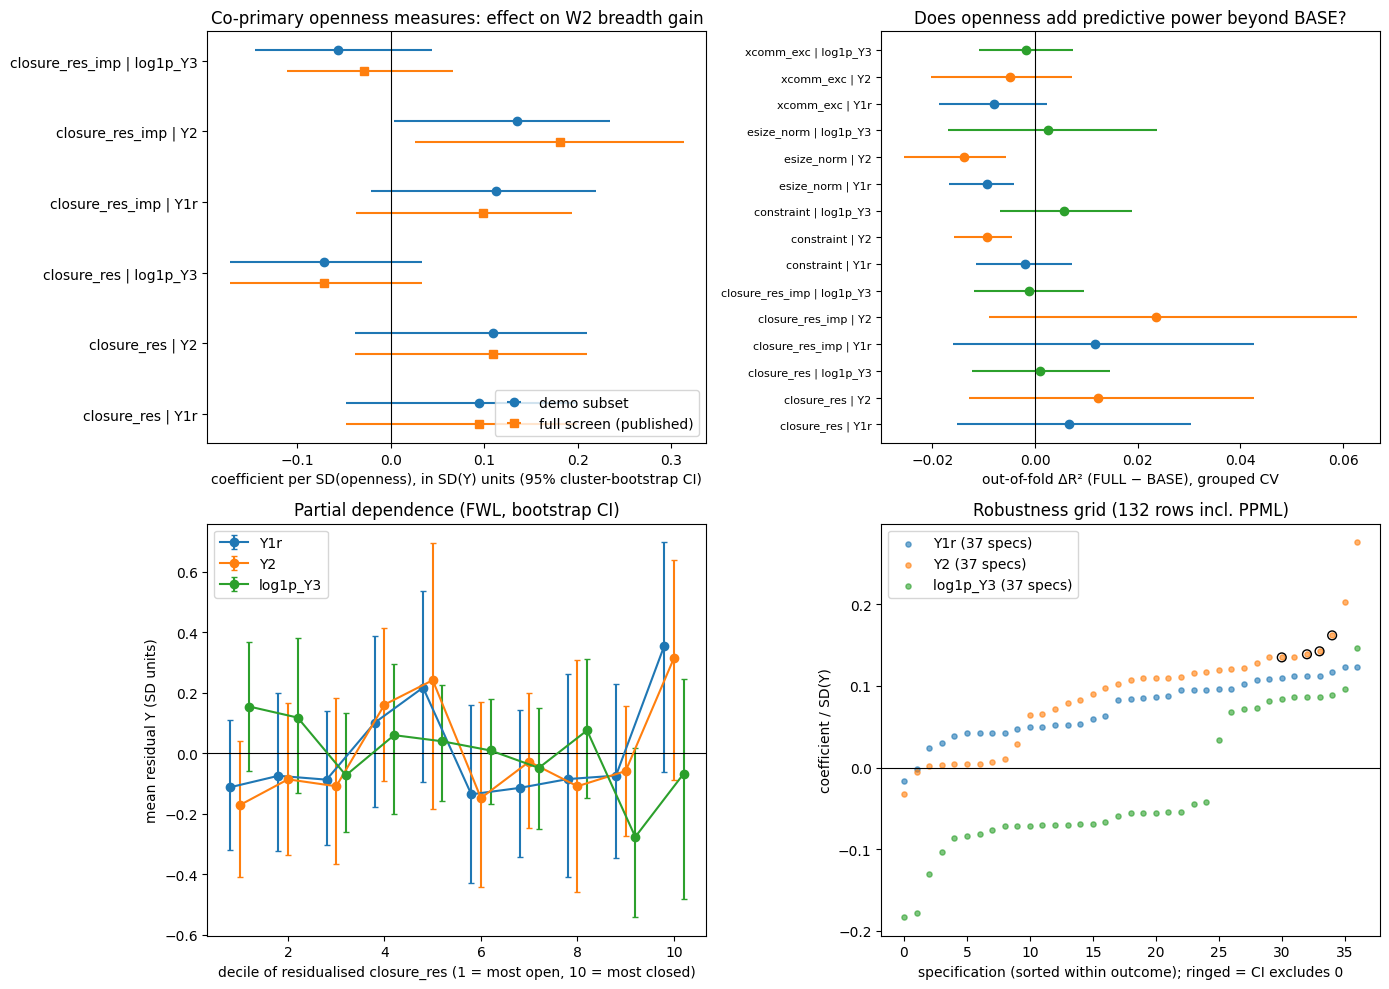

In [18]:
# combined coefficient table (every model x outcome x openness x population), as in models.run()
eup_rows = pd.DataFrame(eup["estimates"]).assign(model="c_within_E_up", population="MAIN")
all_coef = pd.concat([coef, eup_rows[[c for c in eup_rows.columns if not c.startswith("cv_")]],
                      rob.rename(columns={"spec": "model"})], ignore_index=True)
print(f"combined coefficient table: {len(all_coef)} rows\n")

print("=== VERDICT (demo subset):", verdict["verdict"], "| full screen:", data["metadata"]["full_run_verdict"], "===")
print("interpretation:", verdict["interpretation"], "\n")

tab = coef.merge(cv[cv.model == "b_grouped_cv"][["openness", "outcome", "delta_r2", "ci_lo", "ci_hi"]]
                 .rename(columns={"ci_lo": "dR2_lo", "ci_hi": "dR2_hi"}), on=["openness", "outcome"])
tab["coef [95% CI]"] = tab.apply(lambda r: f"{r.coef:+.4f} [{r.ci_lo:+.4f}, {r.ci_hi:+.4f}]", axis=1)
tab["dR2 [95% CI]"] = tab.apply(lambda r: f"{r.delta_r2:+.4f} [{r.dR2_lo:+.4f}, {r.dR2_hi:+.4f}]", axis=1)
tab["rows/concepts"] = tab.n_rows.astype(str) + "/" + tab.n_concepts.astype(str)
print("Table 1 (demo). Openness at t -> W2 breadth gain, MAIN population")
print(tab[["openness", "outcome", "coef [95% CI]", "coef_in_sd_y", "p_boot", "p_holm", "q_bh_secondary", "p_cr1",
           "dR2 [95% CI]", "rows/concepts"]].round(3).to_string(index=False))

full = pd.DataFrame(data["metadata"]["full_run_primary"])
print("\nPublished full-screen estimates (co-primary measures, B=2000)")
print(full.round(4).to_string(index=False))
print("(full-run fold-internal R1a variant, closure_res dR2: Y1r +0.0071, Y2 +0.0122, log1p_Y3 +0.0007 — all CIs include 0)")

print("\nMediation via M_W2 (closure_res_z):")
for y, v in med["closure_res_z"]["per_outcome"].items():
    print(f"  {y:>9}: a={v['a_path']['est']:+.4f}  b={v['b_path']['est']:+.4f}  indirect={v['indirect_ab']['est']:+.4f} "
          f"[{v['indirect_ab']['ci'][0]:+.4f}, {v['indirect_ab']['ci'][1]:+.4f}]  total={v['total_c']['est']:+.4f}")

# ---- figures
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
# (1) forest: demo vs full run
a = ax[0, 0]
labels, k = [], 0
for ov in ["closure_res_z", "closure_res_imp_z"]:
    for y in OUTCOMES:
        r = coef[(coef.openness == ov) & (coef.outcome == y)].iloc[0]
        f = full[(full.openness == ov) & (full.outcome == y)].iloc[0]
        sd = r.sd_y
        a.errorbar(r.coef / sd, k + 0.15, xerr=[[(r.coef - r.ci_lo) / sd], [(r.ci_hi - r.coef) / sd]], fmt="o", color="C0",
                   label="demo subset" if k == 0 else None)
        a.errorbar(f.coef / sd, k - 0.15, xerr=[[(f.coef - f.ci_lo) / sd], [(f.ci_hi - f.coef) / sd]], fmt="s", color="C1",
                   label="full screen (published)" if k == 0 else None)
        labels.append(f"{ov.replace('_z', '')} | {y}")
        k += 1
a.axvline(0, color="k", lw=0.8)
a.set_yticks(range(len(labels)), labels)
a.set_xlabel("coefficient per SD(openness), in SD(Y) units (95% cluster-bootstrap CI)")
a.set_title("Co-primary openness measures: effect on W2 breadth gain")
a.legend(loc="lower right")
# (2) CV delta-R2
a = ax[0, 1]
cvb = cv[cv.model == "b_grouped_cv"].reset_index(drop=True)
for i, r in cvb.iterrows():
    a.errorbar(r.delta_r2, i, xerr=[[r.delta_r2 - r.ci_lo], [r.ci_hi - r.delta_r2]], fmt="o",
               color=f"C{OUTCOMES.index(r.outcome)}")
a.axvline(0, color="k", lw=0.8)
a.set_yticks(range(len(cvb)), [f"{r.openness.replace('_z', '')} | {r.outcome}" for _, r in cvb.iterrows()], fontsize=8)
a.set_xlabel("out-of-fold ΔR² (FULL − BASE), grouped CV")
a.set_title("Does openness add predictive power beyond BASE?")
# (3) partial dependence
a = ax[1, 0]
for j, y in enumerate(OUTCOMES):
    p = pdp[pdp.outcome == y]
    sd = d[y].std()
    a.errorbar(p.decile + (j - 1) * 0.2, p.y_resid_mean / sd, yerr=[(p.y_resid_mean - p.ci_lo) / sd, (p.ci_hi - p.y_resid_mean) / sd],
               fmt="o-", color=f"C{j}", label=y, capsize=2)
a.axhline(0, color="k", lw=0.8)
a.set_xlabel("decile of residualised closure_res (1 = most open, 10 = most closed)")
a.set_ylabel("mean residual Y (SD units)")
a.set_title("Partial dependence (FWL, bootstrap CI)")
a.legend()
# (4) robustness grid
a = ax[1, 1]
ro = rob[rob.estimator == "OLS"].dropna(subset=["coef_in_sd_y"])
for j, y in enumerate(OUTCOMES):
    v = ro[ro.outcome == y].sort_values("coef_in_sd_y")
    excl = (v.ci_lo > 0) | (v.ci_hi < 0)
    a.scatter(np.arange(len(v)), v.coef_in_sd_y, s=14, color=f"C{j}", alpha=0.6, label=f"{y} ({len(v)} specs)")
    a.scatter(np.arange(len(v))[excl.values], v.coef_in_sd_y[excl], s=40, facecolors="none", edgecolors="k")
a.axhline(0, color="k", lw=0.8)
a.set_xlabel("specification (sorted within outcome); ringed = CI excludes 0")
a.set_ylabel("coefficient / SD(Y)")
a.set_title(f"Robustness grid ({len(rob)} rows incl. PPML)")
a.legend()
plt.tight_layout()
plt.show()